# 01 — Foundations
**Referencias:** ESL Cap. 2 (Overview of Supervised Learning) · Géron Cap. 1-2

## El problema de aprendizaje (ESL 2.1)
Dado un conjunto de entrenamiento $\{(x_i, y_i)\}_{i=1}^{N}$, buscamos una función $f(x)$ que minimice el **Expected Prediction Error (EPE)**:

$$\text{EPE}(f) = \mathbb{E}[L(Y, f(X))] = \int L(y, f(x)) \, p(x,y) \, dx \, dy$$

Para pérdida cuadrática $L = (Y - f(X))^2$, la solución óptima es la **función de regresión**:
$$f^*(x) = \mathbb{E}[Y \mid X = x]$$

## Descomposición Bias-Variance (ESL 2.9)
El error de predicción se descompone en tres términos irreducibles:

$$\text{EPE}(x_0) = \underbrace{\sigma^2_{\varepsilon}}_{\text{ruido irreducible}} + \underbrace{\text{Bias}^2[\hat{f}(x_0)]}_{\text{sesgo}} + \underbrace{\text{Var}[\hat{f}(x_0)]}_{\text{varianza}}$$

- **Bias**: error por suposiciones incorrectas del modelo
- **Variance**: sensibilidad del modelo a fluctuaciones en el training set
- **Ruido**: inherente a los datos, no reducible con ningún modelo

In [17]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.family': 'Optima',
})
np.random.seed(42)
print('Setup listo')

Setup listo


## 1 — Dataset: comportamiento de usuarios fintech

In [18]:
n = 1000
sessions        = np.random.randint(1, 20, n)
pages_per_visit = np.random.uniform(1, 8, n)
time_on_site    = np.random.uniform(30, 600, n)
channel         = np.random.choice(['organic','paid','email','direct'], n)
days_since_reg  = np.random.randint(0, 30, n)

days_to_activate = (
    15 - sessions * 0.5 - pages_per_visit * 0.8
    - time_on_site * 0.01 + np.random.normal(0, 2, n)
).clip(1, 30)

df = pd.DataFrame({
    'sessions': sessions, 'pages_per_visit': pages_per_visit.round(2),
    'time_on_site': time_on_site.round(0), 'channel': channel,
    'days_since_reg': days_since_reg, 'days_to_activate': days_to_activate.round(1),
})
print('Shape:', df.shape)
df.head()

Shape: (1000, 6)


,sessions,pages_per_visit,time_on_site,channel,days_since_reg,days_to_activate
0,7,2.90,152.0,email,3,5.9
1,15,5.51,318.0,paid,6,2.5
2,11,3.86,509.0,direct,21,3.4
3,8,1.18,448.0,organic,9,6.7
4,7,2.09,339.0,organic,6,6.2


## 2 — Train / Test Split (Géron Cap. 2)
Regla: **nunca** uses datos de test durante el desarrollo. Son el proxy del mundo real.

In [19]:
X = df[['sessions', 'pages_per_visit', 'time_on_site', 'days_since_reg']]
y = df['days_to_activate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f} días')
print(f'MAE:  {mae:.3f} días')
print(f'R²:   {r2:.3f}')

coef_df = pd.DataFrame({'feature': X.columns, 'coef': model.coef_.round(4)}).sort_values('coef')
print()
print(coef_df.to_string(index=False))

Train: 800 | Test: 200
RMSE: 1.834 días
MAE:  1.487 días
R²:   0.686

        feature    coef
pages_per_visit -0.6116
       sessions -0.3591
 days_since_reg -0.0069
   time_on_site -0.0068


## 3 — Visualizar predicción vs realidad

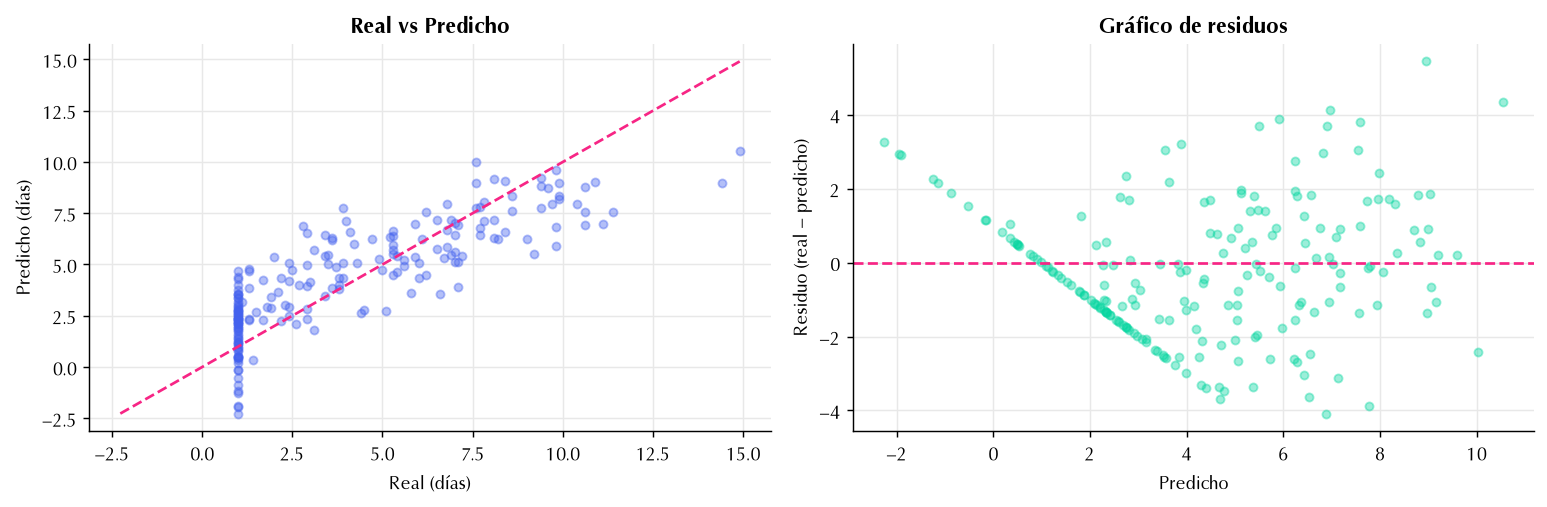

Residuos: media= -0.2308 | std= 1.824


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred, alpha=0.4, color='#4361ee', s=20)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, color='#f72585', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Real (días)'); axes[0].set_ylabel('Predicho (días)')
axes[0].set_title('Real vs Predicho')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='#06d6a0', s=20)
axes[1].axhline(0, color='#f72585', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Residuo (real − predicho)')
axes[1].set_title('Gráfico de residuos')

plt.tight_layout()
plt.show()

# Heterocedasticidad: si los residuos tienen forma de embudo → el modelo tiene problemas
print('Residuos: media=', residuals.mean().round(4), '| std=', residuals.std().round(4))

## 4 — Descomposición Bias-Variance empírica (ESL 2.9)
Estimamos $\text{Bias}^2$ y $\text{Var}$ repitiendo el entrenamiento en B subsets del training set.

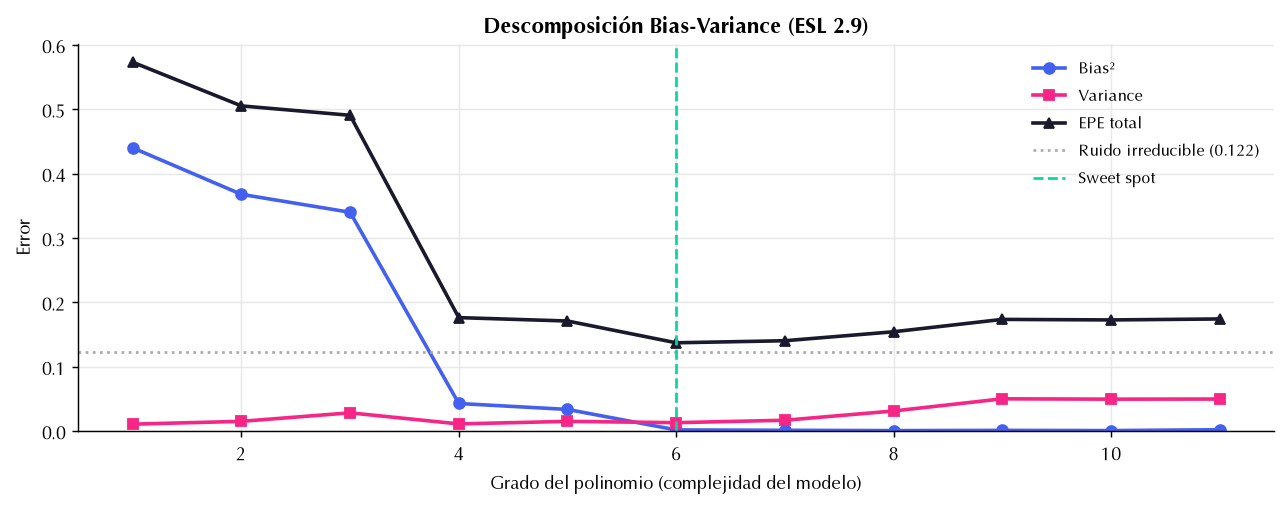

Sweet spot: grado 6
  Bias²=0.0016  Var=0.0129  Ruido=0.1225


In [21]:
def bias_variance_decomp(degree, B=100, n_train=80):
    """
    Estima Bias², Variance y Noise para un modelo polinomial de grado `degree`.
    Usa x aleatorio uniforme (no linspace) para evitar el fenómeno de Runge,
    que hace explotar la varianza en polinomios de grado alto con puntos equiespaciados.
    """
    rng   = np.random.RandomState(0)
    noise = 0.35
    n_all = 500

    # x uniforme aleatorio — estándar en ESL para evitar inestabilidad numérica
    x_all     = rng.uniform(0, 10, n_all)
    y_all     = np.sin(x_all)

    # Test set fijo: grilla densa y ordenada para evaluar
    x_test      = np.linspace(0, 10, 100)
    y_test_true = np.sin(x_test)

    scaler   = StandardScaler().fit(x_all.reshape(-1, 1))
    x_test_s = scaler.transform(x_test.reshape(-1, 1))

    predictions = np.zeros((B, len(x_test)))
    for b in range(B):
        idx  = rng.choice(n_all, n_train, replace=False)
        x_tr = scaler.transform(x_all[idx].reshape(-1, 1))
        y_tr = y_all[idx] + rng.normal(0, noise, n_train)
        pipe = Pipeline([('poly', PolynomialFeatures(degree)), ('lr', LinearRegression())])
        pipe.fit(x_tr, y_tr)
        predictions[b] = pipe.predict(x_test_s)

    mean_pred = predictions.mean(axis=0)
    bias2     = np.mean((mean_pred - y_test_true) ** 2)
    variance  = np.mean(predictions.var(axis=0))
    noise_sq  = noise ** 2
    return bias2, variance, noise_sq, bias2 + variance + noise_sq

degrees = range(1, 12)
results = [bias_variance_decomp(d) for d in degrees]
bias2_l, var_l, noise_l, total_l = zip(*results)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(degrees, bias2_l, 'o-', color='#4361ee', linewidth=2, label='Bias²')
ax.plot(degrees, var_l,   's-', color='#f72585', linewidth=2, label='Variance')
ax.plot(degrees, total_l, '^-', color='#1a1a2e', linewidth=2, label='EPE total')
ax.axhline(noise_l[0], color='#aaa', linestyle=':', linewidth=1.5, label=f'Ruido irreducible ({noise_l[0]:.3f})')
ax.axvline(degrees[np.argmin(total_l)], color='#06d6a0', linestyle='--', linewidth=1.5, label='Sweet spot')

ax.set_xlabel('Grado del polinomio (complejidad del modelo)')
ax.set_ylabel('Error')
ax.set_title('Descomposición Bias-Variance (ESL 2.9)')
ax.legend(fontsize=9)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

print(f'Sweet spot: grado {degrees[np.argmin(total_l)]}')
print(f'  Bias²={bias2_l[np.argmin(total_l)]:.4f}  Var={var_l[np.argmin(total_l)]:.4f}  Ruido={noise_l[0]:.4f}')

## 5 — Overfitting vs Underfitting (visual)

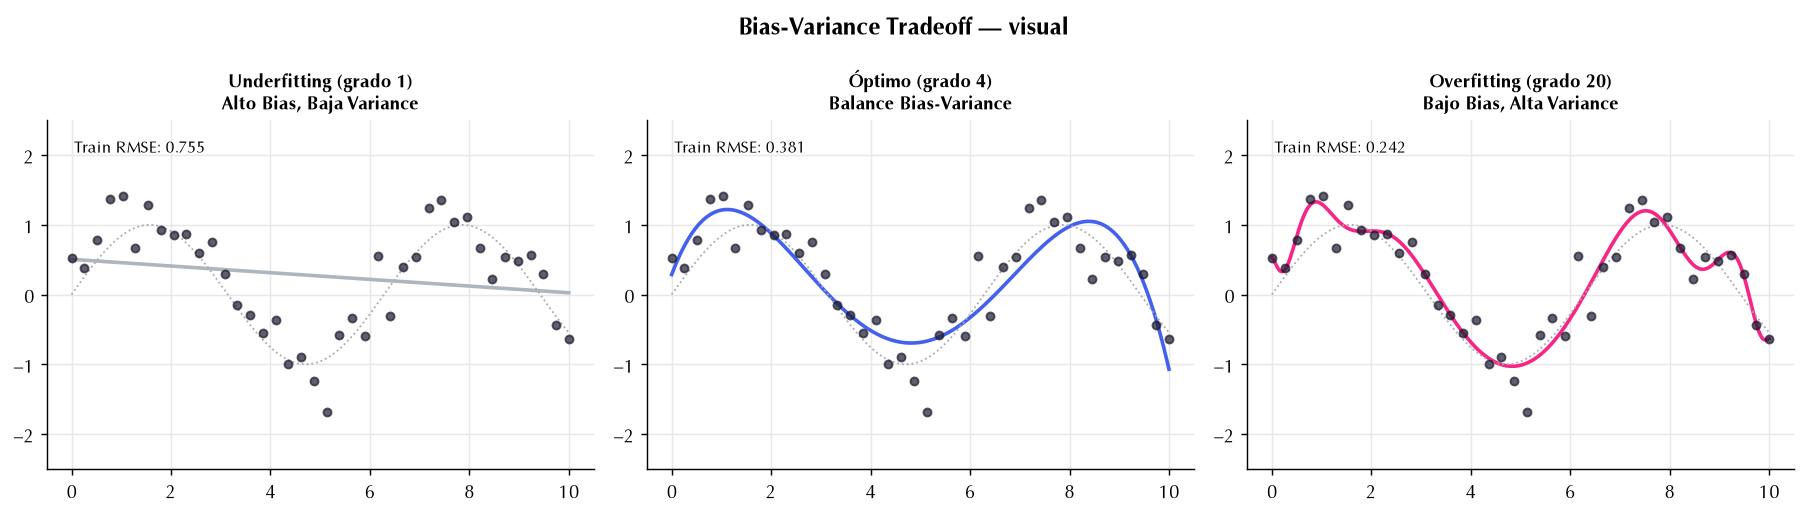

In [22]:
np.random.seed(0)
x_demo = np.linspace(0, 10, 40)
y_demo = np.sin(x_demo) + np.random.normal(0, 0.3, 40)
X_demo = x_demo.reshape(-1, 1)
x_line = np.linspace(0, 10, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
configs = [
    (1,  '#adb5bd', 'Underfitting (grado 1)\nAlto Bias, Baja Variance'),
    (4,  '#4361ee', 'Óptimo (grado 4)\nBalance Bias-Variance'),
    (20, '#f72585', 'Overfitting (grado 20)\nBajo Bias, Alta Variance'),
]

for ax, (degree, color, title) in zip(axes, configs):
    # StandardScaler normaliza x antes de elevar al polinomio.
    # Sin esto, x^20 para x=10 genera valores ~10^20 que rompen
    # la precisión numérica del solver y el modelo no puede overfit.
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(degree)),
        ('lr',     LinearRegression()),
    ])
    pipe.fit(X_demo, y_demo)
    tr_rmse = mean_squared_error(y_demo, pipe.predict(X_demo)) ** 0.5

    ax.scatter(x_demo, y_demo, color='#1a1a2e', s=20, alpha=0.7, zorder=3)
    ax.plot(x_line, pipe.predict(x_line), color=color, linewidth=2)
    ax.plot(x_line, np.sin(x_line), color='#aaa', linewidth=1, linestyle=':', label='f* verdadera')
    ax.set_title(title, fontsize=10)
    ax.set_ylim(-2.5, 2.5)
    ax.text(0.05, 0.95, f'Train RMSE: {tr_rmse:.3f}',
            transform=ax.transAxes, fontsize=9, va='top')

plt.suptitle('Bias-Variance Tradeoff — visual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Métricas de regresión y clasificación

### Regresión
| Métrica | Fórmula | Sensible a outliers |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Sí — penaliza errores grandes |
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | No — más robusta |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | No directamente |

### Clasificación
$$\text{Precision} = \frac{TP}{TP+FP} \quad \text{Recall} = \frac{TP}{TP+FN} \quad F_1 = \frac{2 \cdot P \cdot R}{P+R}$$

**Regla (Géron):** con clases desbalanceadas, Accuracy es engañosa — usa siempre F1 o AUC-ROC.

In [23]:
from sklearn.metrics import mean_absolute_error

model_final = LinearRegression().fit(X_train, y_train)
y_pred_final = model_final.predict(X_test)

rmse = mean_squared_error(y_test, y_pred_final) ** 0.5
mae  = mean_absolute_error(y_test, y_pred_final)
r2   = r2_score(y_test, y_pred_final)

# RMSE siempre >= MAE. Si RMSE >> MAE hay outliers grandes.
print('=== Métricas de regresión ===')
print(f'RMSE:  {rmse:.3f} días')
print(f'MAE:   {mae:.3f} días')
print(f'R²:    {r2:.4f}')
print(f'RMSE/MAE ratio: {rmse/mae:.2f}  (cercano a 1 = pocos outliers)')

=== Métricas de regresión ===
RMSE:  1.834 días
MAE:   1.487 días
R²:    0.6864
RMSE/MAE ratio: 1.23  (cercano a 1 = pocos outliers)


## 7 — No Free Lunch Theorem (ESL 2.8)

> *"Promediando sobre todas las distribuciones posibles de datos, ningún algoritmo supera a otro."* — Wolpert (1996)

**Implicación práctica:** no existe el mejor algoritmo universal. El mejor modelo depende de:
- La estructura real de tus datos
- Tus suposiciones sobre $f^*(x)$
- El balance bias-variance adecuado para tu problema

Por eso siempre se comparan múltiples modelos con cross-validation.

## Resumen

| Concepto | Fórmula / idea clave | Referencia |
|---|---|---|
| EPE | $\text{Bias}^2 + \text{Var} + \sigma^2$ | ESL 2.9 |
| Función de regresión óptima | $f^*(x) = \mathbb{E}[Y \mid X=x]$ | ESL 2.1 |
| Train/Test split | Nunca evaluar con datos de entrenamiento | Géron Cap. 2 |
| No Free Lunch | Ningún modelo es universalmente mejor | ESL 2.8 |
| API sklearn | `.fit()` → `.predict()` → métrica | Géron Cap. 2 |

**Siguiente:** `02_preprocessing.ipynb`